In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from collections import defaultdict
from itertools import product


def subsample(X, y, frequencies, random_state=None):
    """
    Downsample tensor dataset to match target class frequencies.

    Parameters
    ----------
    X : torch.Tensor of shape (N, D)
        Feature tensor.
    y : np.ndarray of shape (N,)
        Category labels.
    frequencies : dict
        Target class frequencies (should sum approx to 1).
    random_state : int, optional
        Seed for reproducibility.

    Returns
    -------
    X_new : torch.Tensor
        Downsampled feature tensor.
    y_new : np.ndarray
        Downsampled labels.
    """

    if random_state is not None:
        torch.manual_seed(random_state)
        np.random.seed(random_state)

    y = np.asarray(y)

    # Normalize frequencies
    frequencies = dict(frequencies)
    total_freq = sum(frequencies.values())
    frequencies = {k: v / total_freq for k, v in frequencies.items()}

    # Current counts
    unique, counts = np.unique(y, return_counts=True)
    current_counts = dict(zip(unique, counts))

    # Determine maximum possible dataset size without oversampling
    target_total = min(
        int(np.floor(current_counts[c] / frequencies[c]))
        for c in frequencies if c in current_counts
    )

    # Compute target counts per class
    target_counts = {
        c: int(round(frequencies[c] * target_total))
        for c in frequencies if c in current_counts
    }

    selected_indices = []

    for c, target_count in target_counts.items():
        class_indices = np.where(y == c)[0]

        if len(class_indices) <= target_count:
            # Keep all if already small enough
            selected_indices.extend(class_indices)
        else:
            # Randomly downsample
            chosen = np.random.choice(class_indices, size=target_count, replace=False)
            selected_indices.extend(chosen)

    selected_indices = np.array(selected_indices)

    # Shuffle final indices
    np.random.shuffle(selected_indices)

    X_new = X[selected_indices]
    y_new = y[selected_indices]

    return X_new, y_new


def set_seed(seed):
    """Ensure full reproducibility."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Make operations deterministic (can slow down slightly)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_acc_lp(feats_q, feats_db, labels_q, labels_db, frequencies=None, random_state=None, epochs=50, lr=0.1):
    """
    Linear probe: trains a single linear classifier on feats_db and evaluates on feats_q.
    Handles string labels automatically by encoding to integers.
    Prints test accuracy every 10 epochs.

    Parameters
    ----------
    feats_q : torch.Tensor [n_query, d]
        Query embeddings.
    feats_db : torch.Tensor [n_db, d]
        Database embeddings.
    labels_q : np.ndarray or list [n_query]
        Query labels (can be strings).
    labels_db : np.ndarray or list [n_db]
        Database labels (can be strings).
    frequencies : dict, optional
        If provided, downsample feats_db/labels_db to match class frequencies.
    random_state : int, optional
        Seed for reproducibility.
    epochs : int
        Number of training epochs.
    lr : float
        Learning rate.

    Returns
    -------
    methods : dict
        {'linear_probe': accuracy}
    """

    if random_state is not None:
        torch.manual_seed(random_state)
        np.random.seed(random_state)

    feats_db = F.normalize(feats_db, p=2)
    feats_q = F.normalize(feats_q, p=2)

    labels_db = np.array(labels_db)
    labels_q = np.array(labels_q)

    # --- Encode string labels to integers ---
    unique_labels = np.unique(labels_db)
    label2idx = {label: i for i, label in enumerate(unique_labels)}
    y_train = torch.tensor([label2idx[l] for l in labels_db], dtype=torch.long)
    y_test = torch.tensor([label2idx[l] for l in labels_q], dtype=torch.long)

    # --- Downsample DB if frequencies provided ---
    if frequencies is not None:
        # Map string labels in frequencies to integers
        freq_int = {label2idx[k]: v for k, v in frequencies.items() if k in label2idx}
        feats_db, y_train_np = subsample(
            feats_db, y_train.numpy(),
            frequencies=freq_int,
            random_state=random_state
        )
        y_train = torch.tensor(y_train_np, dtype=torch.long)

    X_train = feats_db
    X_test = feats_q

    n_classes = len(unique_labels)
    d = feats_db.shape[1]

    # --- Linear classifier ---
    linear = nn.Linear(d, n_classes, bias=True)
    optimizer = torch.optim.SGD(linear.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # --- Training loop ---
    linear.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        logits = linear(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()

    # --- Final evaluation ---
    linear.eval()
    with torch.no_grad():
        logits = linear(X_test)
        preds = logits.argmax(dim=1)
        acc = (preds == y_test).float().mean().item()

    methods = {'linear_probe': acc}
    return methods


def get_results(test_feats, feats_train, repeats=10, seed=42, epochs=100, lr=0.1):
    set_seed(seed)
    lp_results = []
    for i in range(repeats):
        data = []
        for crop in ['bbox', 'full']:
            crop_results = get_acc_lp(
                feats_db=feats_train[crop],
                feats_q=test_feats[crop],
                labels_db = labels_sim,
                labels_q = labels_real,
                frequencies=frequencies,
                epochs=epochs,
                lr = lr
            )
            for method, acc in crop_results.items():
                data.append({
                    'method': method,
                    'crop': crop,
                    'acc': acc,
                })
        df = pd.DataFrame(data)
        lp_results.append(df.set_index('crop')['acc'])
    
    return pd.DataFrame(lp_results)



frequencies = {
    'single': 0.33547113961519487,
    't-bone': 0.3241243216576221,
    'rear-end': 0.16181549087321165,
    'sideswipe': 0.12086827824370992,
    'head-on': 0.05772076961026147
}

## Load features

In [95]:
# Real feats
results = torch.load('results/cls_knn_dinov2.pkl', weights_only=False)
labels_real = np.stack([i['type'] for i in results])

feats_real_dino = {}
feats_real_dino['bbox'] = torch.stack([result['feats'][1] for result in results])
feats_real_dino['full'] = torch.stack([result['feats'][2] for result in results])


# Sim feats
results = torch.load('results/cls_knn_sim_dinov2.pkl', weights_only=False)
labels_sim = np.stack([i['type'] for i in results])

feats_sim_dino = {}
feats_sim_dino['bbox'] = torch.stack([result['feats'][1] for result in results])
feats_sim_dino['full'] = torch.stack([result['feats'][2] for result in results])


# Molmo end to end
results = torch.load('results/feats_pred_molmo_dinov2.pkl', weights_only=False)
feats_pred_molmo_dino = {}
feats_pred_molmo_dino['bbox'] = torch.stack([result['feats'][0] for result in results])
feats_pred_molmo_dino['full'] = torch.stack([result['feats'][1] for result in results])

In [96]:
# Real feats
results = torch.load('results/cls_knn_siglip.pkl', weights_only=False)
labels_real = np.stack([i['type'] for i in results])

feats_real_siglip = {}
feats_real_siglip['bbox'] = torch.stack([result['feats'][1] for result in results])
feats_real_siglip['full'] = torch.stack([result['feats'][2] for result in results])


# Sim feats
results = torch.load('results/cls_knn_sim_siglip.pkl', weights_only=False)
labels_sim = np.stack([i['type'] for i in results])

feats_sim_siglip = {}
feats_sim_siglip['bbox'] = torch.stack([result['feats'][1] for result in results])
feats_sim_siglip['full'] = torch.stack([result['feats'][2] for result in results])


# Molmo end to end
results = torch.load('results/feats_pred_molmo_siglip.pkl', weights_only=False)

feats_pred_molmo_siglip = {}
feats_pred_molmo_siglip['bbox'] = torch.stack([result['feats'][0] for result in results])
feats_pred_molmo_siglip['full'] = torch.stack([result['feats'][1] for result in results])

## Linear probe - DINO v2

In [98]:
get_results(feats_real_dino, feats_sim_dino, epochs=500, lr=0.1).mean()

crop
bbox    0.362654
full    0.440602
dtype: float64

In [99]:
get_results(feats_pred_molmo_dino, feats_sim_dino, epochs=500, lr=0.1).mean()

crop
bbox    0.379724
full    0.433300
dtype: float64

## Linear probe - Siglip

In [100]:
get_results(feats_real_siglip, feats_sim_siglip, epochs=500, lr=0.1).mean()

crop
bbox    0.470794
full    0.397928
dtype: float64

In [101]:
get_results(feats_pred_molmo_siglip, feats_sim_siglip, epochs=500, lr=0.1).mean()

crop
bbox    0.38737
full    0.39482
dtype: float64

# Features visualization

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def scatter_plot_sources(feats_sim, labels_sim, feats_real, labels_real, title="Simulated vs Real Embeddings"):
    """
    Scatter plot of simulated vs real feature sets with class coloring and source markers.

    Parameters
    ----------
    feats_sim : torch.Tensor or np.ndarray [n1, d]
        Features from simulated data.
    labels_sim : list or np.ndarray [n1]
        Labels from simulated data.
    feats_real : torch.Tensor or np.ndarray [n2, d]
        Features from real data.
    labels_real : list or np.ndarray [n2]
        Labels from real data.
    title : str
        Plot title.
    """
    
    # Convert to numpy if torch tensors
    if hasattr(feats_sim, "detach"):
        feats_sim = feats_sim.cpu().numpy()
    if hasattr(feats_real, "detach"):
        feats_real = feats_real.cpu().numpy()

    labels_sim = np.array(labels_sim)
    labels_real = np.array(labels_real)

    # Combine features and labels
    feats = np.vstack([feats_sim, feats_real])
    labels = np.concatenate([labels_sim, labels_real])
    sources = np.array(["Simulated"] * len(feats_sim) + ["Real"] * len(feats_real))

    # --- Project to 2D if necessary ---
    if feats.shape[1] > 2:
        pca = PCA(n_components=2, random_state=42)
        feats_2d = pca.fit_transform(feats)
    else:
        feats_2d = feats

    # Create DataFrame for Seaborn
    df = pd.DataFrame({
        "x": feats_2d[:, 0],
        "y": feats_2d[:, 1],
        "class": labels,
        "source": sources
    })

    # --- Plot ---
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df,
        x="x",
        y="y",
        hue="class",
        style="source",
        markers={"Simulated": "o", "Real": "X"},
        palette="tab10",
        s=20,
        alpha=0.8
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.show()

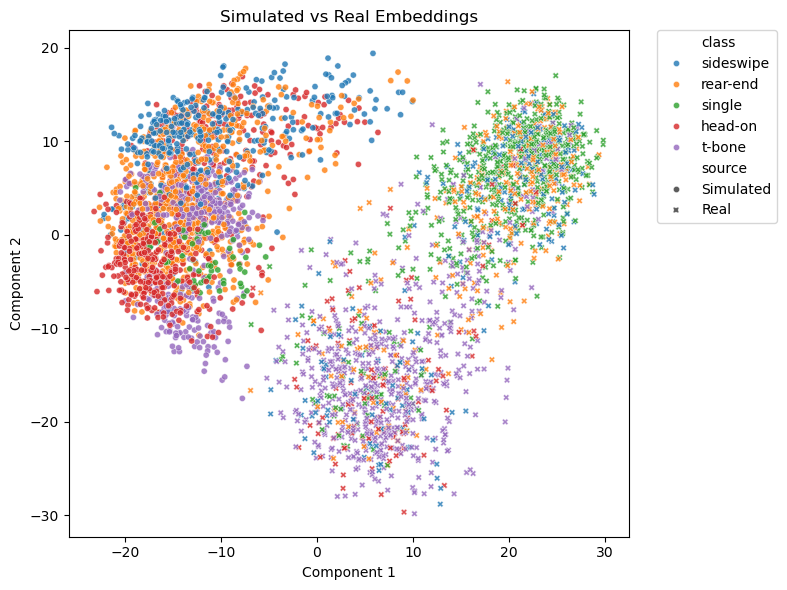

In [50]:
%matplotlib inline

crop = 'full'
scatter_plot_sources(
    feats_sim=feats_sim_dino[crop],
    feats_real=feats_real_dino[crop],
    labels_sim = labels_sim,
    labels_real = labels_real,
)